In [18]:
using Pkg
Pkg.add(url="https://github.com/fernandopenaranda/Optics_in_the_length_gauge")

    Updating git-repo `https://github.com/fernandopenaranda/Optics_in_the_length_gauge`
   Resolving package versions...
    Updating `~/Documents/Work/PostdocDonosti/Packages/LMC/Project.toml`
  [0ea70cc5] ~ Optics_in_the_length_gauge v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main` ⇒ v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main`
    Updating `~/Documents/Work/PostdocDonosti/Packages/LMC/Manifest.toml`
  [0ea70cc5] ~ Optics_in_the_length_gauge v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main` ⇒ v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main`
Precompiling project...
  ✓ Optics_in_the_length_gauge
  ✓ LMC
  2 dependencies successfully precompiled in 8 seconds. 186 already precompiled.
  2 dependencies precompiled but different versions are currently loaded. Restart julia to access the new versions


In [1]:
using Pkg
Pkg.activate(dirname(dirname(pwd())))   # activate MyPackage
# Pkg.instantiate()
using Revise
using LMC
using LinearAlgebra
using Optics_in_the_length_gauge
# using CairoMakie

  Activating project at `~/Documents/Work/PostdocDonosti/Packages/LMC`


In [2]:
using CairoMakie, Colors

Loaded plotting extension


## Cluster

In [ ]:
# important everytime you update a program
rm -rf /scratch/$USER/julia_depot/compiled
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.precompile()'

# copy from cluster to local
# rsync -avz ferpe@hyperion.sw.ehu.es:/dipc/ferpe/Projects/LMC /Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output

In [64]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp  =  LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah =  LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")
s = simportedvp

Self_consistent_data([[0.09177345774687988, 0.9082266953889119, 0.09177332560351777, 0.9082265632458201, 0.09177345774707828, 0.9082266953886995, 0.09177332560324447, 0.90822656324608], [0.09511348277570118, 0.9082511047894717, 0.09488496101520044, 0.9082363274508053, 0.09506482891973579, 0.9082485860070545, 0.09488496101520041, 0.9082363274508], [0.09837451965982014, 0.9082578457346432, 0.09819466351798244, 0.9082466677698788, 0.09837451965980154, 0.9082578457346596, 0.09819466212611173, 0.908246668566111], [0.10245915358429471, 0.9083252464279664, 0.10138957737766345, 0.9082700970840478, 0.1014245880034912, 0.9082721917421305, 0.10138957737766344, 0.908270097084047], [0.1063219445813836, 0.908357447941392, 0.10450540358549186, 0.9082591487666652, 0.10465143137966329, 0.9082700749993093, 0.10450540358549182, 0.908259148766665], [0.10919545986212188, 0.9083505993834553, 0.10789113601393205, 0.9082876665175774, 0.10893827608404896, 0.9083380869167671, 0.107891136013932, 0.90828766651757

In [45]:
l = LMC.readparams(folder)
pimported = ParamsHF(paramsHF(1.05, 1,  1),
    μ = 0,
    nf = l.nf[1],
    λ = l.λ[1],
    M = l.M[1],
    v = l.v[1],
    vp = l.vp[1],
    γ =l.γ[1],
    sigmaz = l.sigmaz[1],
    sigmazlayerz = l.sigmazlayerz[1],
    U1 = l.U1[1],
    U2 = l.U2[1],
    J = 0*l.J[1],
    VP =l.VP[1],
    twovalleystwospins= l.twovalleystwospins[1]);
p = pimported

ParamsHF
  μ: Float64 0.0
  θ: Float64 1.05
  ν: Int64 1
  nmax: Int64 1
  pointsk: Int64 30
  v: Float64 -7000.0
  vp: Float64 2000.0
  vpp: Float64 -0.0332
  M: Float64 5.0
  γ: Float64 -30.0
  λ: Float64 140.0
  U1: Float64 5.0
  U2: Float64 0.0
  n: Float64 0.0
  nf: Float64 1.0
  sigmaz: Float64 2.5
  sigmazlayerz: Float64 0.0
  layerz: Float64 0.0
  vafek: Float64 0.0
  c2ybreakingmass: Float64 0.0
  J: Float64 0.0
  VP: Bool true
  twovalleys: Bool false
  twovalleystwospins: Bool true
  KIVC: Bool false


In [107]:
# HYP Drudes: 
drude_vec = [4663708,4663506,4637376]
# HYP LMC: [ 4616767, 4617898 , 4618700,  4619343]
lmc_vec = [4663298, 4662818, 4659748,4658685,4657197, 4656436, 4652639,4651517,4650903,4650379,4649541,4648753]

#out put response calculations
drudePID = drude_vec[1]#4619927#4612639 #4604805
qahlmcPID =  4679928#4679575#4677674#4677493 #4674849
vplmcPID = 4679575#4677674 #4674611#4667654


drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
qahlmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(qahlmcPID)_merged_data.jld"
qahlmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(qahlmcPID)_merged_presets.jld"
vplmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(vplmcPID)_merged_data.jld"
vplmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(vplmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4679575_merged_presets.jld"

## Calculations

In [55]:
T = 100
νval = 0.1
it = argmin(abs.(s.ns .- νval))

6

In [56]:
# @time lmc_orb_sweep(folder, "qah", evals = 10, T = 0.5) .* 1000
# evals = [10,100,500,1000, 2500,10000, 20000, 40000]
evals = [10,100,1000]
s = simportedvp
vvp2 = [linear_magneto_conductivity_orbital(xxx_lmc_presets(ParamsHF(p, μ = s.mus[it]),  diagm(s.ofmats[it]), evals = e, T = 2)) *1e3 for e in evals]

3-element Vector{Float64}:
 0.002219858043140712
 0.037383221450926346
 0.004536304803285826

In [26]:

s = simportedqah
vqah2 = [linear_magneto_conductivity_orbital(xxx_lmc_presets(ParamsHF(p, μ = s.mus[it]),  diagm(s.ofmats[it]), evals = e, T = 2)) *1e3 for e in evals]

8-element Vector{Float64}:
  0.04975669122069323
 -0.012107203093528671
  0.00032001079534537075
  0.000687797259467752
  0.000482101491119418
  0.0018867400146153285
  0.001878242436006356
  0.0019418914168590406

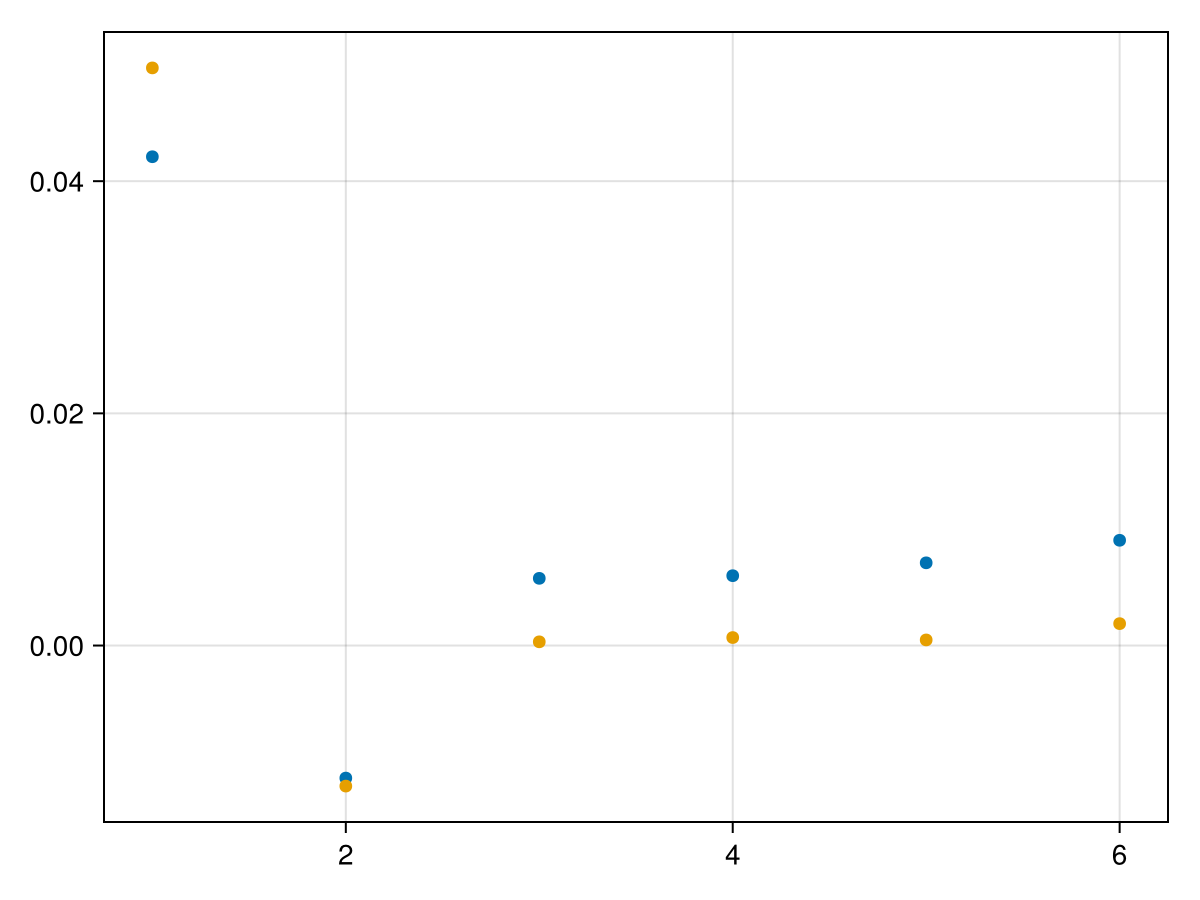

In [24]:
fig = Figure()
ax = Axis(fig[1,1])
scatter!(ax,  vvp)
scatter!(ax,  vqah)
fig

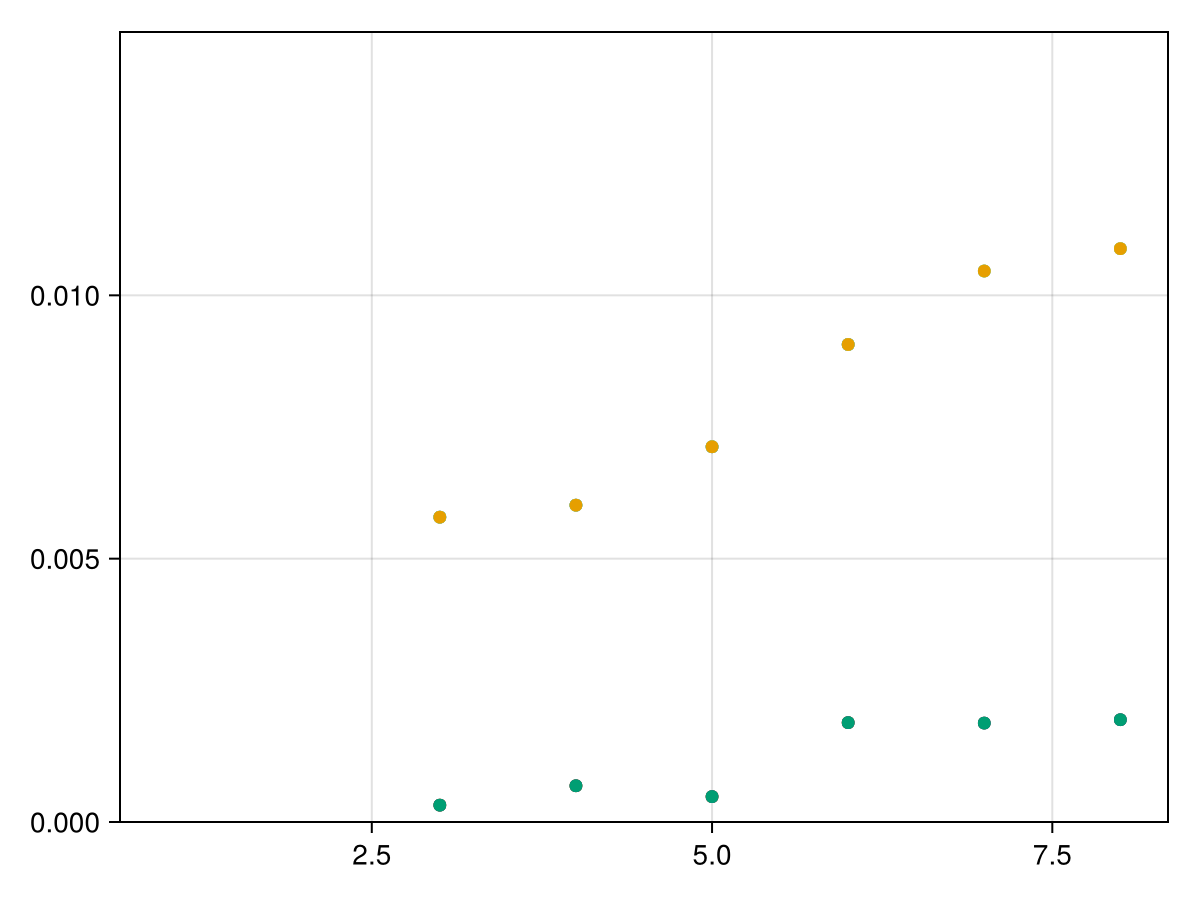

In [30]:
fig2 = Figure()
ax2 = Axis(fig2[1,1])
scatter!(ax,  vvp2)
scatter!(ax,  vqah2)
ylims!(ax, [0,0.015])
fig

In [58]:
ns, mcqah = mc_sweep(:x, :x, :x, pimported, simportedqah; 
    T = 1, τ = 200, evals = 100, Ω_contr = true, omm_contr = true, fermi_surface = false)

UndefVarError: UndefVarError: `mc_sweep` not defined

In [ ]:
vspins = lmc_spin_sweep(folder, "vp", evals = 2)

In [7]:
vdrude = drude_sweep(folder, "vp", evals = 100, T= 5)

progress: 0.025 |  val: 0.1734567625997456
progress: 0.05 |  val: 0.1668770022574668
progress: 0.075 |  val: 0.14107281012927234
progress: 0.1 |  val: 0.11175809556966525
progress: 0.125 |  val: 0.08598587433292183
progress: 0.15 |  val: 0.06797386613461325
progress: 0.175 |  val: 0.056800616490346685
progress: 0.2 |  val: 0.05047546355829977
progress: 0.225 |  val: 0.04695376658136439
progress: 0.25 |  val: 0.04197068585191574
progress: 0.275 |  val: 0.05337628320564371
progress: 0.3 |  val: 0.05469378699444103
progress: 0.325 |  val: 0.05678938134924128
progress: 0.35 |  val: 0.058643696568588144
progress: 0.375 |  val: 0.0587067660652104
progress: 0.4 |  val: 0.05744193031336905
progress: 0.425 |  val: 0.06260018781990415
progress: 0.45 |  val: 0.05211962132703605
progress: 0.475 |  val: 0.04756835155544052
progress: 0.5 |  val: 0.04319902157708077
progress: 0.525 |  val: 0.06292798939005372
progress: 0.55 |  val: 0.06532495987787086
progress: 0.575 |  val: 0.0411876096449874
progre

([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.1734567625997456, 0.1668770022574668, 0.14107281012927234, 0.11175809556966525, 0.08598587433292183, 0.06797386613461325, 0.056800616490346685, 0.05047546355829977, 0.04695376658136439, 0.04197068585191574  …  0.060178433582912354, 0.05557019017690123, 0.033792962411281, 0.019243839787228992, 0.014512677505239494, 0.0099171299752345, 0.008573649145848697, 0.009925190371115767, 0.013535309082904906, 0.01978002876638205])

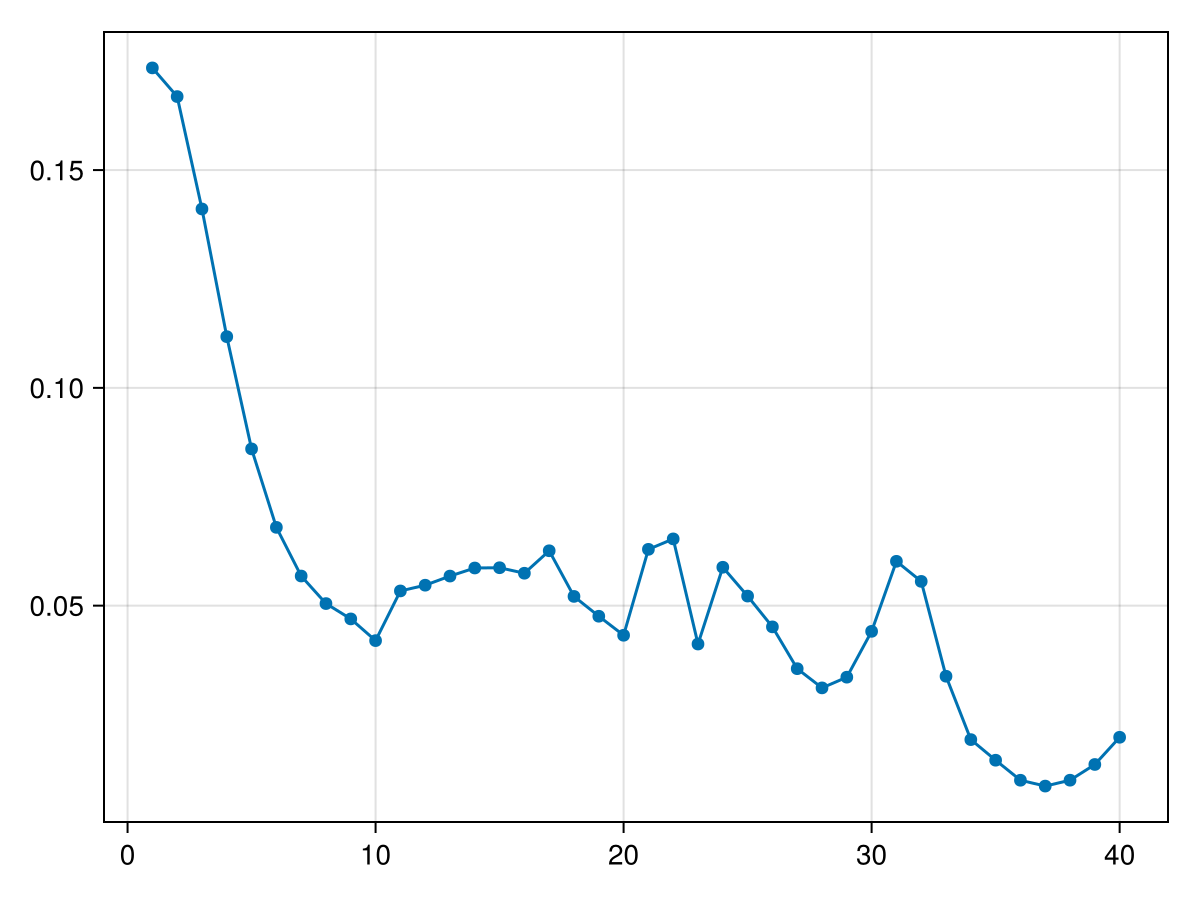

In [8]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(ax,  [v for v in vdrude[2]])
scatter!(ax,  [v for v in vdrude[2]])
fig

In [158]:
13/2.46^2

2.1481922136294536

## Plots

In [75]:
using CairoMakie, LaTeXStrings, JLD2, Colors


In [71]:
# External calculation for the k-meshes

# Define number of grid points 
T = 5
νval = 2.5
it = argmin(abs.(s.ns .- νval))
n = 50
p = pimported
svp = simportedvp
sqah = simportedqah

pxxxvp = xxx_lmc_presets(ParamsHF(p, μ = svp.mus[it]), diagm(svp.ofmats[it]), T = T, fermi_surface = true) 
integrandvp(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxvp, q) 

pxxxqah = xxx_lmc_presets(ParamsHF(p, μ = sqah.mus[it]), diagm(sqah.ofmats[it]), T = T, fermi_surface = true) 
integrandqah(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxqah, q) 


M, xmin, xmax = LMC.int_boundaries(p)
# a = [0, xmin[2]];
# b = [xmax[1]/2, xmax[2]];
a = [-xmax[1], xmin[2]];
b = [xmax[1], xmax[2]];

# Generate grid points
x = range(a[1], b[1], length=n)
y = range(a[2], b[2], length=n)

# Evaluate f on the grid
Zvp = [integrandvp([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering
Zqah = [integrandqah([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering

In [156]:

using Interpolations, Statistics


#choose solution at boundary region
function interpolate_despike(x,y, threshold)
    good = detect_outliers(y, threshold)
    xg = x[good]
    yg = y[good]
    itp = linear_interpolation(xg, yg, extrapolation_bc = Line())
    return itp.(x)
end

function detect_outliers(data::AbstractVector{<:Real}, threshold::Real)
    n = length(data)
    good = trues(n)
    for i in 2:n-1
        avg_neighbors = (data[i-1] + data[i+1]) / 2
        if abs(data[i] - avg_neighbors) > threshold
            good[i] = false
        end
    end
    return good
end

function despike_forward!(d, threshold)
    data = zeros(length(d))
    n = length(data)
    data[1] = d[1]
    for i in 2:n-1
        left  = data[i-1]      # already filtered
        mid   = d[i]
        right = d[i+1]      # original (not yet filtered)

        avg_neighbors = (left + right) / 2
        deviation = abs(mid - avg_neighbors)

        if deviation > threshold && abs(right)-abs(mid) > threshold && abs(left)-abs(mid) > threshold || deviation > 10threshold
        data[i] = avg_neighbors
        else 
            data[i] = d[i]
        end
    end

    return data
end

function lat_tbg_figure(drudepresetpath, drudepath, qahlmcpresetpath, qahlmcpath, vplmcpresetpath, vplmcpath, folder = 2281278; fontsize = 14, ylims = [-0.002,0.02])
    with_theme(merge(theme_latexfonts(), Theme(fontsize = fontsize))) do #
        tbg_figure(drudepresetpath, drudepath, qahlmcpresetpath, qahlmcpath, vplmcpresetpath, vplmcpath, folder; ylims = ylims, fontsize = fontsize)   
    end
end

function tbg_figure(drudepresetpath, drudepath, qahlmcpresetpath, qahlmcpath, vplmcpresetpath, vplmcpath, folder; fontsize = 12, ylims = [0,0.02])
    figtbg = Figure(size = (600, 600),figure_padding = (0,0,0,0))
    ax1 = Axis(figtbg[2,1], height = 100, xlabel = "ν", ylabel = L"$|\langle \tau_z \rangle_\text{f}|$", xlabelsize = fontsize +2, ylabelsize = fontsize +2,ylabelpadding = 17)
    ga = figtbg[1,1] = GridLayout()
    ax2 = Axis(figtbg[3,1], xlabel = "ν", ylabel = L"$\sigma_{xxx}^{(S,1)}B_x/\sigma_{xx}\text{ [%]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    hidexdecorations!(ax1, grid = false)

    simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
    simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")
    t1 = tauz(simportedvp)
    t2 = tauz(simportedqah)
    fig = Figure()
    
    col = parse(Colorant, "#FF34FFFF")
    lines!(ax1, simportedvp.ns, t1, label =  L"$\text{VP}" , color = col)
    lines!(ax1, simportedvp.ns, t2, label =  L"$\text{VH/SVH}$", color = :black)
    ylims!(ax1, -0.1, 2)

    ylims!(ax2, ylims[1], ylims[2])
    axislegend(ax1, position = :lt, labelsize = fontsize -2, orientation = :horizontal)
    ax1.yticks = [0,1,2]
    xlims!(ax1, 0,4)
    xlims!(ax2, 0,4)
    vlines!(ax1, 2.5, color = :lightgray, linewidth = 1, linestyle = :dash)


    vspan!(ax1, 2.2,2.75, color = (:gray, 0.3))
    vspan!(ax2, 2.2,2.75, color = (:gray, 0.3))

    
    myidx = argmin(abs.(simportedvp.ns .- 2.5))
    scatter!(ax1, [2.5], [t1[myidx]], marker = Rect, markersize = 8, color = col, clip = false)
    scatter!(ax1, [2.5], [t2[myidx]], marker = Rect, markersize = 8, color = :black, clip = false)
    


    #_________________________________________#_________________________________________
    νsd, drudevals = aux_plot_tbg_obs(drudepresetpath, drudepath)
    νsqah, qahvals = aux_plot_tbg_obs(qahlmcpresetpath, qahlmcpath)
    νs, vpvals = aux_plot_tbg_obs(vplmcpresetpath, vplmcpath)
    # y_interp = interpolate_despike( [ν for ν in νs],[obs for obs in vals], 50)
    vqah =  [obs for obs in qahvals]
    vdrude =  [obs for obs in drudevals]
    vvp =  [obs for obs in vpvals]

    # lines!(ax2, [ν for ν in νsqah],  vdrude )#./  (vdrude ) )
    # lines!(ax2, [ν for ν in νsd],  vdrude)#./  vdrude )
    

    lines!(ax2, [ν for ν in νsqah],  100 * 10 .*   vqah )#./  (vdrude ) )
    lines!(ax2, [ν for ν in νs],  100 * 10 .* vpvals )#./  vdrude )
    # ylims!(ax2, -0.0001, 0.02)
    # lines!(ax2, [ν for ν in νs], vdrude )

    # lines!(ax2, [ν for ν in νs],  vdrude , color = :red)
    tbg_bands_mesh!(ga, fontsize)
    rowgap!(figtbg.layout, 0)
    Label(ga[1, 1, TopLeft()], "a)",
    fontsize = fontsize,
    padding = (0, 35, -0, 0),
    halign = :right)

    Label(ga[1, 2, TopLeft()], "b)",
    fontsize = fontsize,
    padding = (0, 5, -0, 0),
    halign = :right)

    Label(figtbg[2, 1, TopLeft()], "c)",
    fontsize = fontsize,
    padding = (0, 35, -10, 0),
    halign = :right)


    Label(figtbg[3, 1, TopLeft()], "d)",
    fontsize = fontsize,
    padding = (0, 35, -0, 0),
    halign = :right)
    figtbg
end

function tbg_bands_mesh!(ga, fontsize = 14)
    col = parse(Colorant, "#FF34FFFF")
    vis = 1e21
    ϵ = abs(xmin[2]) / 100
    ax1 = Axis(ga[1, 1], xlabel=L"$k_x$", ylabel=L"$k_y$", title=L"$\text{|\tau_z| = 0}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2, titlesize = fontsize+2, ylabelpadding = -7)
    ax2 = Axis(ga[1, 2], xlabel=L"$kx$", ylabel=L"$ky$", title=L"$\text{|\tau_z| \neq 0}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2, titlesize = fontsize+2)
    val = maximum(abs.(Zqah))
    # heatmap!(ax, x, y, Z, colormap=:redsblues)#, colorrange=(-1, 1.0).*vis)
    hm = heatmap!(ax1, x, y, -Zqah ./ val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
    BZdecorations!(p, ax1)
    hm = heatmap!(ax2, x, y, -Zvp ./ val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
    BZdecorations!(p, ax2)
    xlims!(ax1, a[1]-ϵ, b[1]+ϵ)
    ylims!(ax1, a[2]-ϵ, b[2]+ϵ)
    xlims!(ax2, a[1]-ϵ, b[1]+ϵ)
    ylims!(ax2, a[2]-ϵ, b[2]+ϵ)
    
    ax2.xticks = [-0.03,0, 0.03]
    ax1.yticks = [-0.03,0, 0.03] , ["-0.03","0", "0.03"] 
    scatter!(ax1, [100], [100], color = :black, label = "", marker = :rect, markersize = 20, clipping = false)
    scatter!(ax2, [100], [100], color = col, label = "", marker = :rect, markersize = 20, clipping = false)
    axislegend(ax1,  framevisible = false, backgroundcolor = (:white, 0.5), backgroundvisible = false,   position = :lt, padding = (0,0,0,0), margin = (0,-7,0,0))
    axislegend(ax2,  framevisible = false, backgroundvisible = false,   position = :lt, padding = (0,0,0,0), margin = (0,-10,0,0))

    

    # scatter!(ax1, ,color)
    # cb = Colorbar(ga[1, 3], hm)
    cb = Colorbar(
    ga[1, 3];
    colormap = hm.colormap[],
    colorrange = (0, 1),
    ticks = [0, 1], label = L"$-\partial f/ \partial \epsilon_{k}$", labelpadding = -10)
    hideydecorations!(ax2)
 
    # Colorbar(fig[1,2], ax)  # Add a colorbar
end

function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end

function BZdecorations!(p, ax)
    G1, G2 = LMC.bravais_vectors(p);     
    K1 =  LMC.κ(G1, G2)
    K2 =  LMC.κ(G2, G1)
    scatter!(ax, K1[1], K1[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K2[1], K2[2], color = :blue, marker = :x, markersize = 10)
    scatter!(ax, K1[1]-G1[1], K1[2]-G1[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K1[1]-G2[1]-G1[1], K1[2]-G2[2]-G1[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K1[1]-G2[1], K1[2]-G2[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K2[1]-G2[1], K2[2]-G2[2], color = :blue, marker = :x, markersize = 10)
    scatter!(ax, K2[1]-G1[1]-G2[1], K2[2]-G1[2]-G2[2], color = :blue, marker = :x, markersize = 10)
    scatter!(ax, [0, G1[1],G2[1],-G1[1],-G2[1],G1[1]+G2[1],-G1[1]-G2[1]], 
             [0,G1[2],G2[2],-G1[2],-G2[2],G1[2]+G2[2],-G1[2]-G2[2]], 
            color = :black, marker = :x, markersize = 10)
    lines!(ax, [0, G1[1], G1[1]+G2[1], G2[1] , 0], 
             [0, G1[2],  G1[2]+G2[2], G2[2] , 0], 
            color = :black, linestyle = :dash)
end


BZdecorations! (generic function with 1 method)

In [209]:
# HYP Drudes: 
drude_vec = [4663506,4637376] #4663708,
# HYP LMC: [ 4616767, 4617898 , 4618700,  4619343]
lmc_vec = [4663298, 4662818, 4659748,4658685,4657197, 4656436, 4652639,4651517,4650903,4650379,4649541,4648753]

myvec =[4689268, 4690496, 4693505, 4694361, 4695687, 4696421, 4680325, 4686388]
myvec = [4719068, 4716004, 4713272,  4704490, 4711019, 4698739, 4699071, 4699450, 4699739]
myvec = [4713272, 4716004, 4719068, 4704490, 4711019]
myvec = [4721455, 4722149]#4680325
# myvec = [4726575, 4727693] # old method same as in the paper
#out put response calculations
drudePID = drude_vec[1]#4619927#4612639 #4604805
qahlmcPID =  myvec[1]#4680325#4679928#4679575#4677674#4677493 #4674849
vplmcPID = myvec[2]#4680325#myvec[2]#4686388# #4679575#4677674 #4674611#4667654

drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
qahlmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(qahlmcPID)_merged_data.jld"
qahlmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(qahlmcPID)_merged_presets.jld"
vplmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(vplmcPID)_merged_data.jld"
vplmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(vplmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4727693_merged_presets.jld"

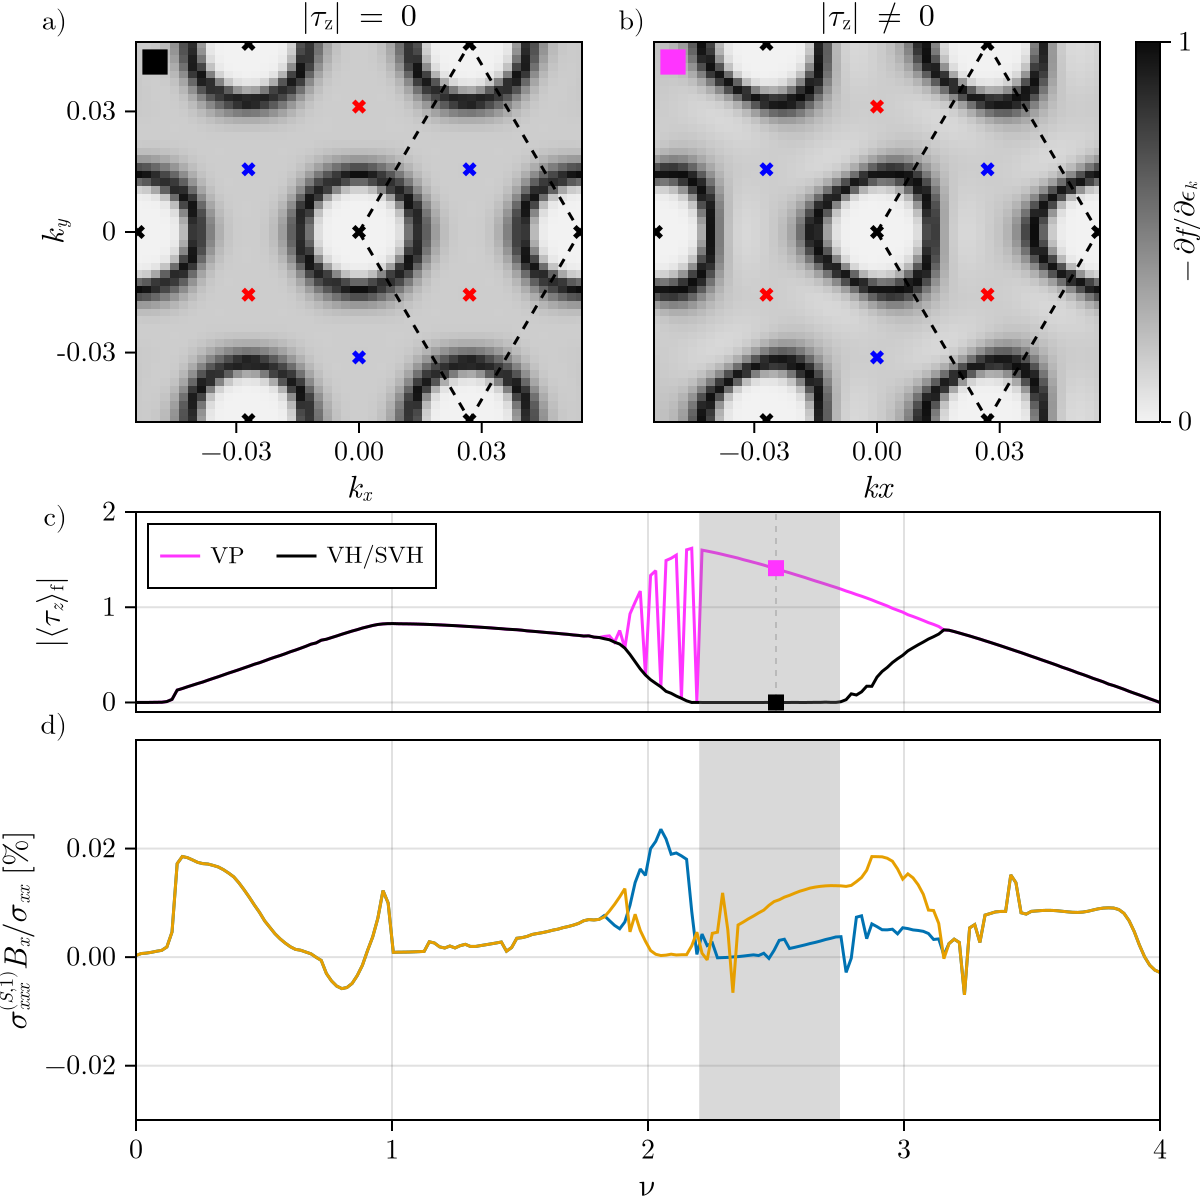

In [210]:
fig = lat_tbg_figure(drudepresetpath, drudepath, qahlmcpresetpath, 
    qahlmcpath, vplmcpresetpath, vplmcpath, ylims = [-0.03,0.04
])

In [373]:
# v = "v1"
# save("/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/Figures/Figurelmctbg$(v).pdf", fig)

CairoMakie.Screen{PDF}


## Fss

In [481]:
T = 2
νval = 2.5
it = argmin(abs.(s.ns .- νval))

125

In [468]:

# Create the density plot
using CairoMakie
# Define number of grid points
T = 2
νval = 1.9
it = argmin(abs.(s.ns .- νval))
n = 20
p = pimported
svp = simportedvp
sqah = simportedqah

pxxxvp = xxx_lmc_presets(ParamsHF(p, μ = svp.mus[it]), diagm(svp.ofmats[it]), T = T, fermi_surface = true) 
integrandvp(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxvp, q) 

pxxxqah = xxx_lmc_presets(ParamsHF(p, μ = sqah.mus[it]), diagm(sqah.ofmats[it]), T = T, fermi_surface = true) 
integrandqah(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxqah, q) 


M, xmin, xmax = LMC.int_boundaries(p)
# a = [0, xmin[2]];
# b = [xmax[1]/2, xmax[2]];
a = [-xmax[1], xmin[2]];
b = [xmax[1], xmax[2]];

# Generate grid points
x = range(a[1], b[1], length=n)
y = range(a[2], b[2], length=n)

# Evaluate f on the grid
Zvp = [integrandvp([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering
Zqah = [integrandqah([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering



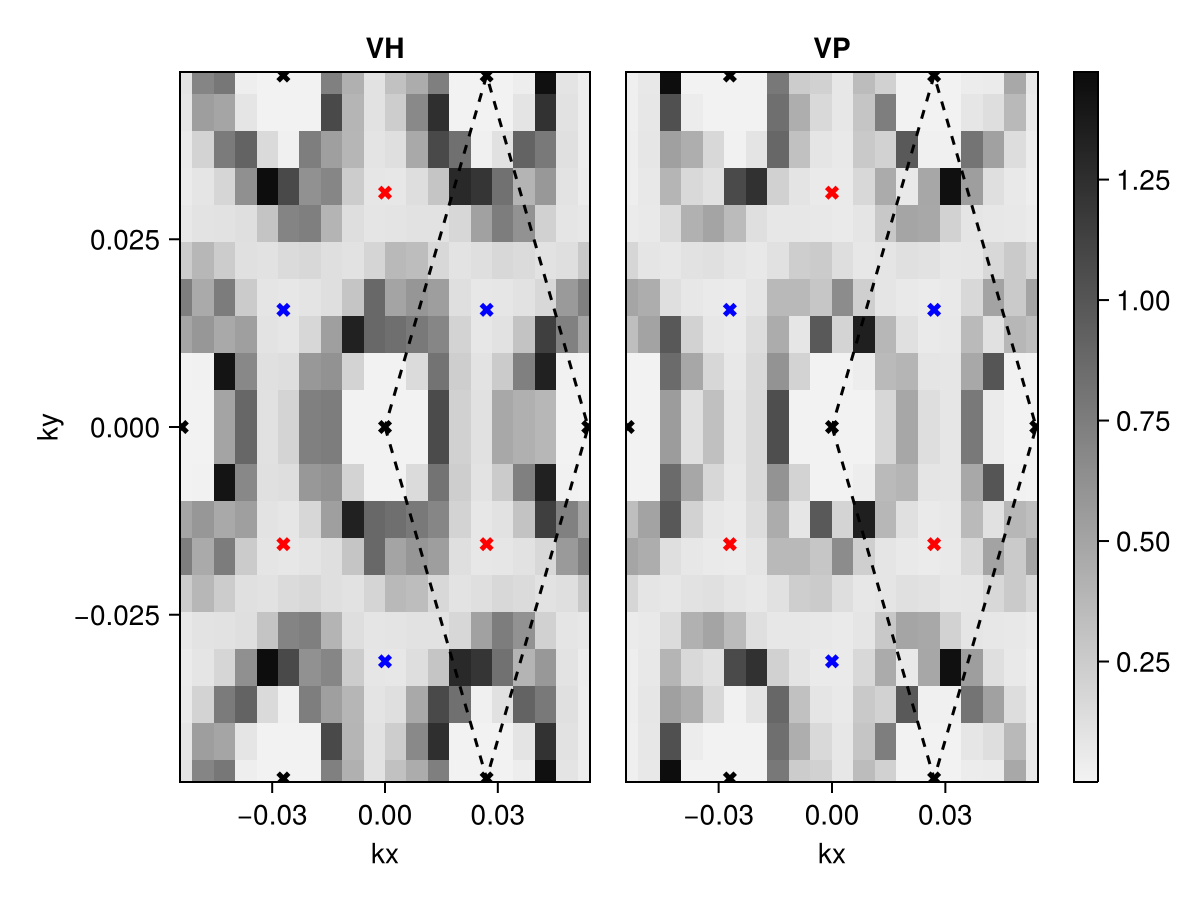

In [469]:

fig = Figure()
vis = 1e21
ϵ = abs(xmin[2])/100
ax1 = Axis(fig[1, 1], xlabel="kx", ylabel="ky", title="VH")
ax2 = Axis(fig[1, 2], xlabel="kx", ylabel="ky", title="VP")
val = maximum(abs.(Zqah))
# heatmap!(ax, x, y, Z, colormap=:redsblues)#, colorrange=(-1, 1.0).*vis)
hm = heatmap!(ax1, x, y, -Zqah ./val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
BZdecorations!(p, ax1)

hm = heatmap!(ax2, x, y, -Zvp ./ val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
BZdecorations!(p, ax2)
xlims!(ax1, a[1]-ϵ, b[1]+ϵ)
ylims!(ax1, a[2]-ϵ, b[2]+ϵ)

xlims!(ax2, a[1]-ϵ, b[1]+ϵ)
ylims!(ax2, a[2]-ϵ, b[2]+ϵ)
cb = Colorbar(fig[1, 3], hm)
hideydecorations!(ax2)

# Colorbar(fig[1,2], ax)  # Add a colorbar
fig

In [470]:
νval = 2.05
it = argmin(abs.(s.ns .- νval))
sqah.ofmats[it] # valley balanced
#pos valley[spin up] # neg valley [spin up] # pos valley [spin down] #neg valley [spin down]

8-element Vector{Float64}:
 0.8854469151724772
 0.9009756590223479
 0.6944686760345885
 0.9009963807326375
 0.10173359473089207
 0.8872163571302631
 0.11155275112474561
 0.8870348972152635

In [471]:
svp.ofmats[it] #valley imbalanced

8-element Vector{Float64}:
 0.8854469151724772
 0.9009756590223479
 0.10173420981796742
 0.8872174985525306
 0.6944686760345885
 0.9009963807326375
 0.11155275112474561
 0.8870348972152635

In [458]:
νval2 = 2.1
it2 = argmin(abs.(s.ns .- νval2))
sqah.ofmats[it2] #valley balanced


8-element Vector{Float64}:
 0.8846365921475333
 0.9003103505452031
 0.7882583050899047
 0.9003544649807939
 0.09448068732543806
 0.8851158020690097
 0.09448068732543816
 0.885115802069009

In [459]:
svp.ofmats[it2] # valley imbalanced

8-element Vector{Float64}:
 0.8846365921475333
 0.9003103505452031
 0.09448068732543806
 0.8851158020690097
 0.7882583050899047
 0.9003544649807939
 0.09448068732543816
 0.885115802069009

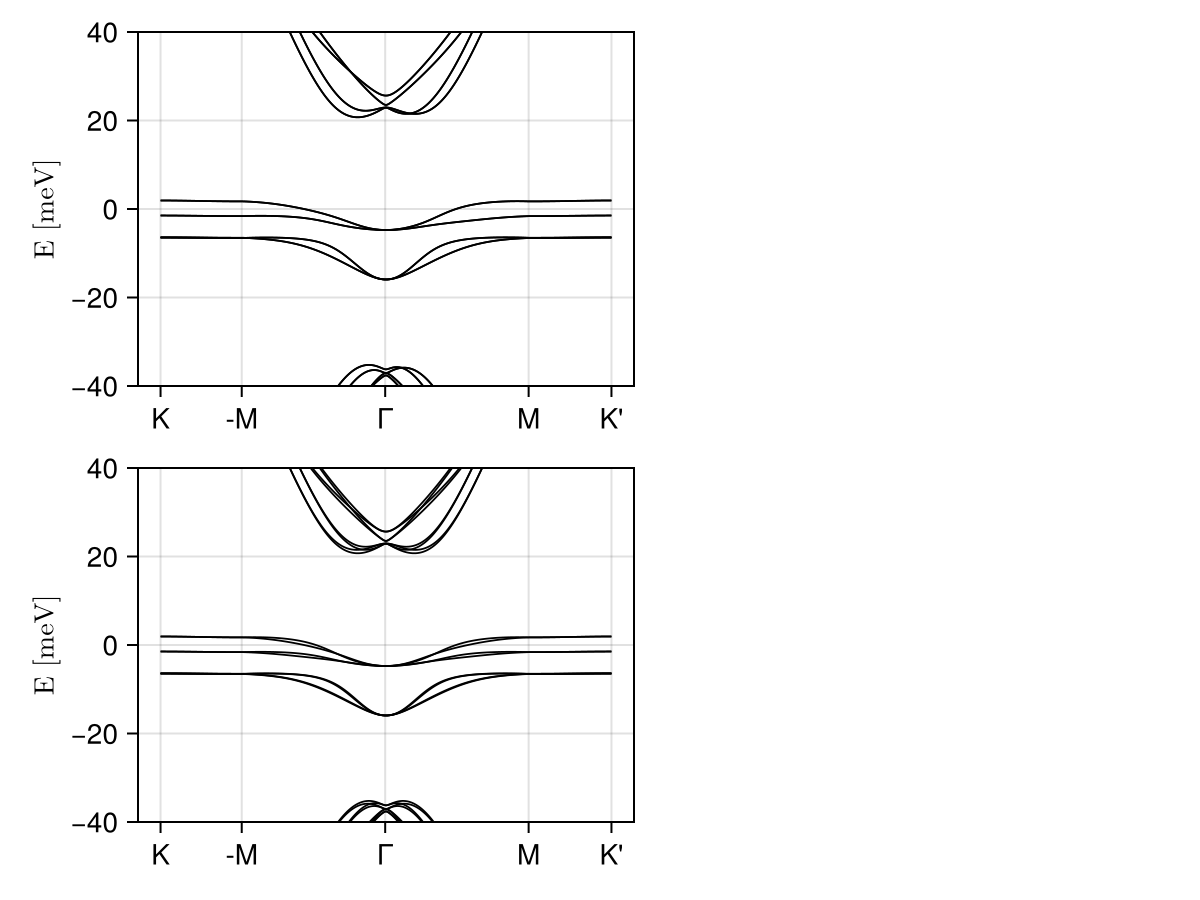

In [427]:
it = argmin(abs.(s.ns .- νval))
p = pimported
svp = simportedvp
sqah = simportedqah


fig = Figure()
ax1 = Axis(fig[1,1], ylabel = L"$\text{E [meV]}$")
ax2 = Axis(fig[2,1], ylabel = L"$\text{E [meV]}$")
ga = fig[1:2,2] = GridLayout()

LMC.plotmybands!(ax1, real.(LMC.bands(ParamsHF(p, μ = svp.mus[it]), diagm(svp.ofmats[it]), 101)),
      ylimits = [-40,40], color = :black)

LMC.plotmybands!(ax2, real.(LMC.bands(ParamsHF(p, μ = sqah.mus[it]), diagm(sqah.ofmats[it]), 101)),
      ylimits = [-40,40], color = :black)
# LMC.plotmybands!(ax2, real.(LMC.bands(ParamsHF(p, μ = 0, sigmaz = 5), ones(8),  101)), 
#       ylimits = ylims, xlimits = xlimits, color = :black, linewidth = linewidth)
    
    
fig


## Tests

In [295]:
lat_tbg_figure(drudepresetpath, drudepath, qahlmcpresetpath, qahlmcpath, vplmcpresetpath, vplmcpath)abs

MethodError: MethodError: no method matching *(::Figure, ::typeof(abs))

Closest candidates are:
  *(::Any, ::Any, !Matched::Any, !Matched::Any...)
   @ Base operators.jl:578
  *(!Matched::Multisets.Multiset, ::T) where T
   @ Multisets ~/.julia/packages/Multisets/6iSi0/src/operations.jl:174
  *(!Matched::SpecialFunctions.SimplePoly, ::Any)
   @ SpecialFunctions ~/.julia/packages/SpecialFunctions/mf0qH/src/expint.jl:8
  ...


In [284]:
y_interp = interpolate_despike([ν for ν in νs],v, 80)
using Interpolations

UndefVarError: UndefVarError: `νs` not defined

In [148]:
y_interp

200-element Vector{Float64}:
 76.8880745647023
 79.97980911524468
 83.07154366578706
 31.403817937449087
 23.57435111413298
 70.7992371222872
 22.81551927075506
 86.04849090636564
 46.24109346204932
 32.89235926528871
  ⋮
 78.54750700685872
 71.66389995312079
 64.78029289938272
 43.393432019510115
 50.95516817168751
 42.694005524297665
 30.113083690322814
 83.30452577604483
 54.284438352927324

In [163]:
# HYP Drudes: 
drude_vec = [4637376]
# HYP LMC: [ 4616767, 4617898 , 4618700,  4619343]
lmc_vec = [4655329, 4652639,4651517,4650903,4650379,4649541,4648753]

#out put response calculations
drudePID = drude_vec[1]#4619927#4612639 #4604805
lmcPID = lmc_vec[1]

drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
lmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(lmcPID)_merged_data.jld"
lmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(lmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4655329_merged_presets.jld"

In [164]:
νs, vals = aux_plot_tbg_obs(lmcpresetpath, lmcpath)

(Any[0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.00734005031571599, 0.06136501241776696, 0.0037150396890558673, 0.0023401463528735173, 0.00019132838150650664, 0.00048565140907882797, 0.0046619709493812425, 0.003720710802534254, 0.022202166843886137, 0.010467138871635803  …  0.037428495857213494, 0.007273295980541842, 0.0010962994270106263, 0.04840734931629278, 0.005582173903558919, 0.00424892147293919, 0.0016480365615801837, 0.002261171474230182, 0.006141149010802994, 0.042125288903634955])

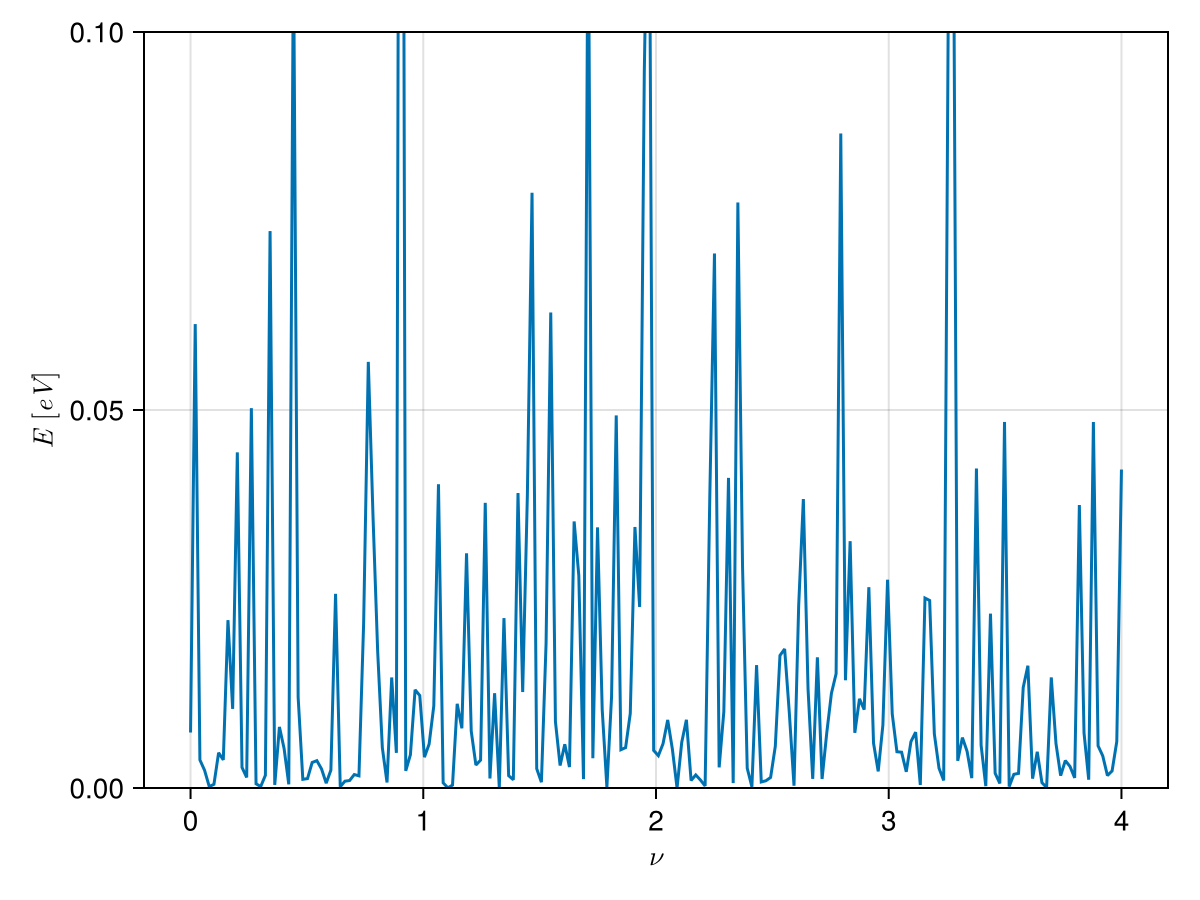

In [166]:
using Interpolations
fig = Figure()
ax = Axis(fig[1,1], xlabel = L"$\nu$", ylabel = L"$E\text{ }[eV]$")
nus = [ν for ν in νs]
v = [obs for obs in vals]
y_interp = interpolate_despike( [ν for ν in νs],v, 80)
Interpolations.interpolate((nus,), (v), Gridded(Linear()))
ylims!(ax, 0, 0.1)
lines!(ax, nus ,y_interp)
fig


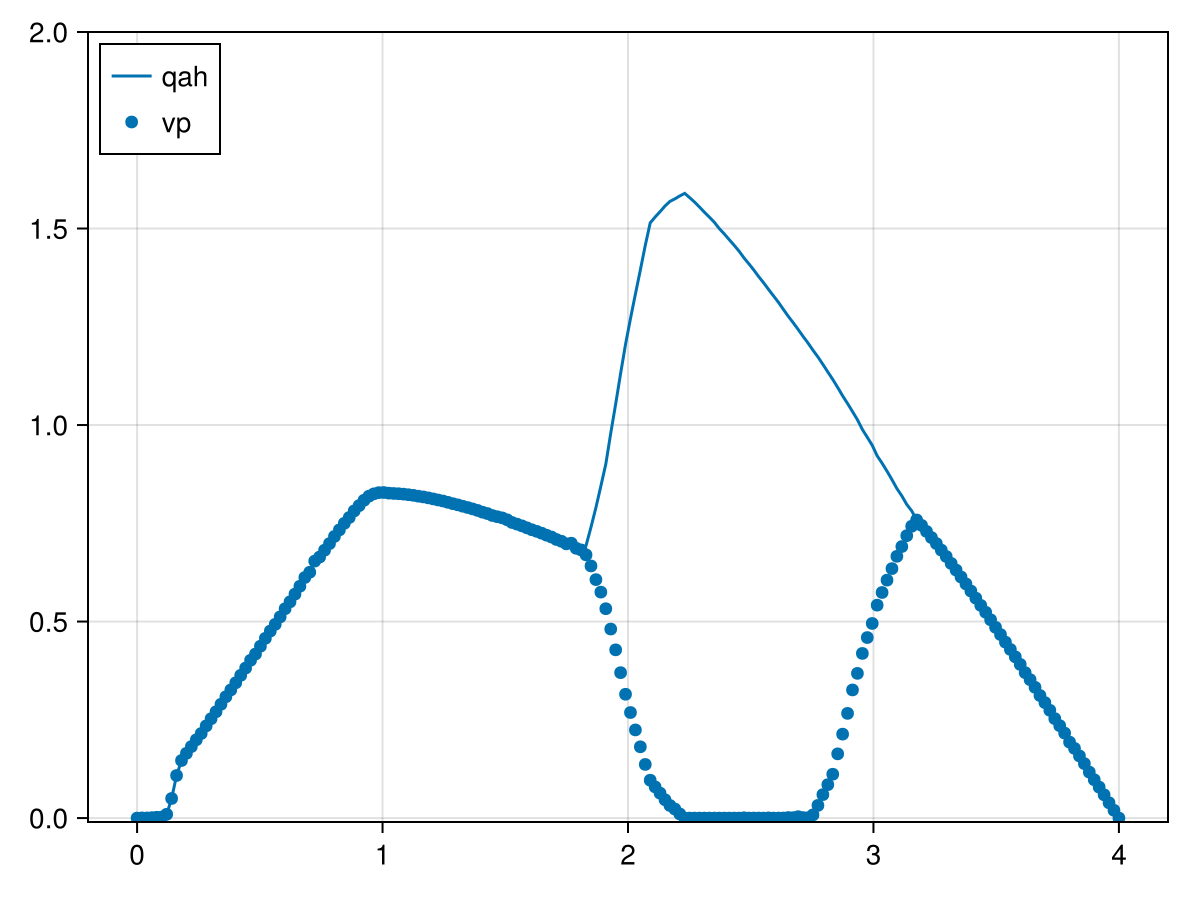

In [172]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")

function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end
t1 = tauz(simportedvp)
t2 = tauz(simportedqah)
fig = Figure()
ax = Axis(fig[1,1]) 
lines!(ax, simportedvp.ns, t1, label = "qah")
scatter!(ax, simportedvp.ns, t2, label = "vp")
ylims!(ax, -0.01, 2)
axislegend(ax, position = :lt)
fig

## Tests

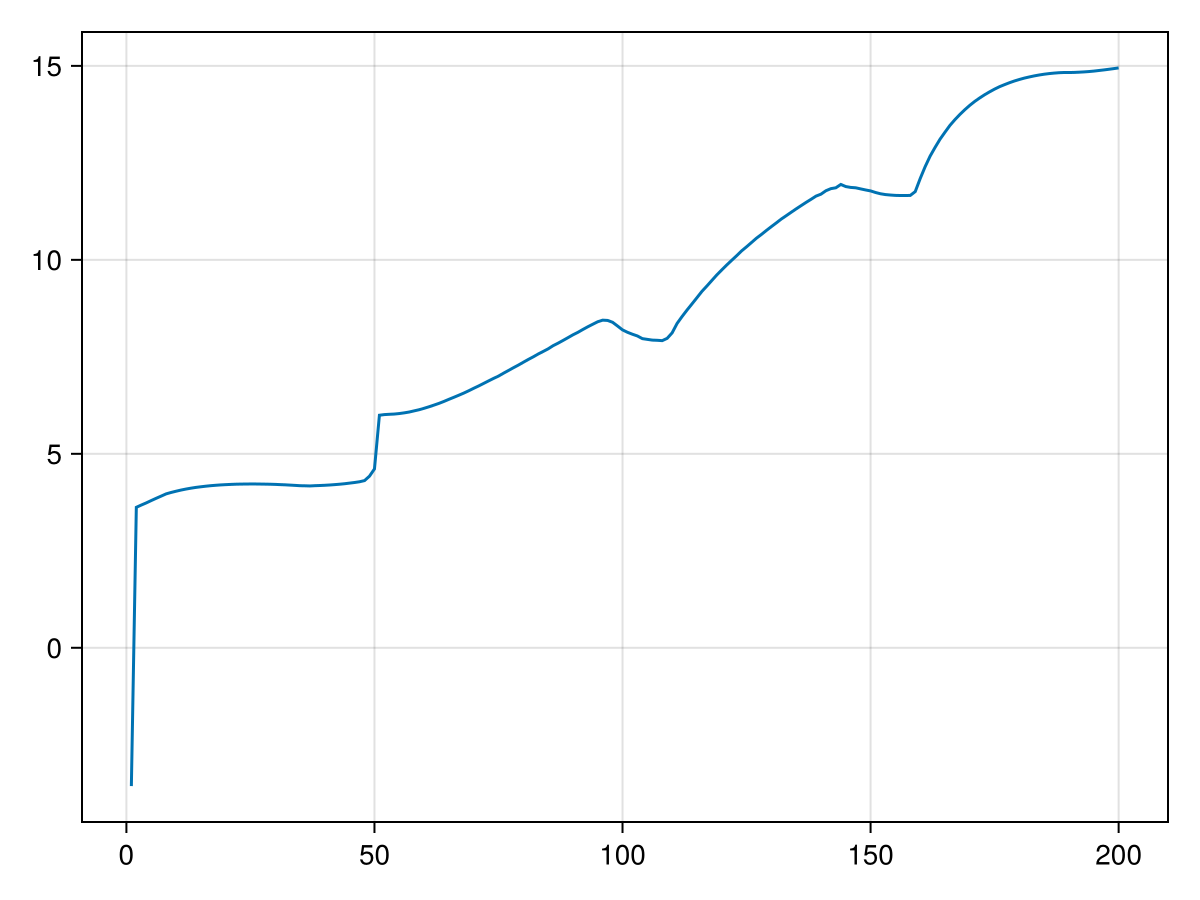

In [21]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(ax, simportedvp.mus)
fig

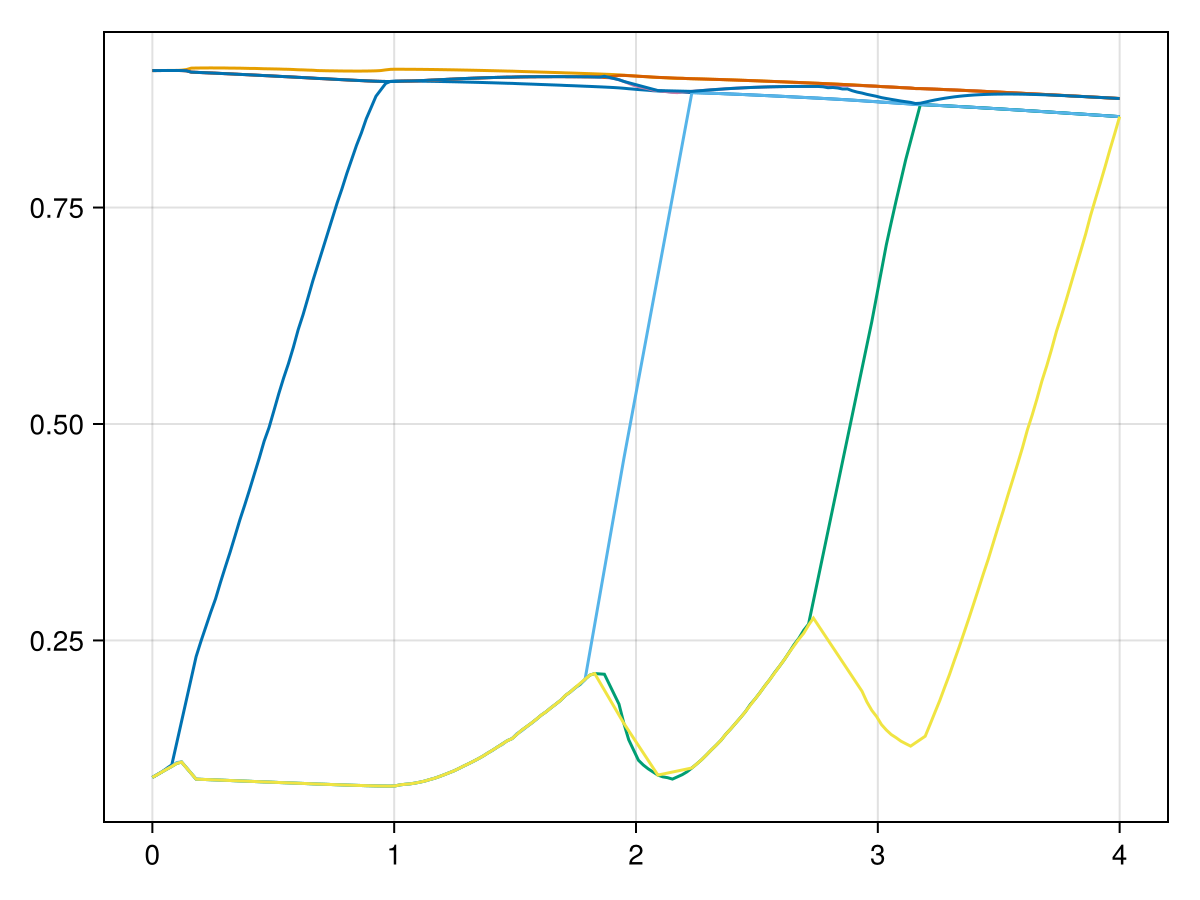

In [114]:
fig = Figure()
ax = Axis(fig[1,1])
s = simportedvp

[lines!(ax, s.ns, intnss[it]) for it in 1:8]
fig
# lines!(ax, simportedqah.ofmats[8])

In [89]:
"""
self-consistent magnetoconductivity sweep with filling
"""
function mc_sweep(p, s::Self_consistent_data; evals = 10, T=1)
    mc_arr = []
    for (it,ν) in enumerate(s.ns)
        if it % 10 == 0
            prs = xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[it]), diagm(s.ofmats[it]), T = T, evals = evals)
            mc = linear_magneto_conductivity_orbital(prs)
            append!(mc_arr, mc)
            println("progress: ", it/length(s.ns)," |  val: ", mc)
        end
    end
    return s.ns, mc_arr
end

mc_sweep

In [90]:
@time ns, mcqah = mc_sweep(pimported, simportedqah, T = 1000, evals = 1000)
    

progress: 0.05 |  val: 0.007445122653333354
progress: 0.1 |  val: 0.007203439664739912
progress: 0.15 |  val: 0.007652735916616184
progress: 0.2 |  val: 0.006256052895803186
progress: 0.25 |  val: 0.006372928688283411
progress: 0.3 |  val: 0.001199742751498212
progress: 0.35 |  val: 0.0010982067617763594
progress: 0.4 |  val: -0.0012180969704891418
progress: 0.45 |  val: 0.0028160957773728343
progress: 0.5 |  val: 0.008215652670132108
progress: 0.55 |  val: 0.0007379576914120238
progress: 0.6 |  val: -0.0010617957239967722
progress: 0.65 |  val: -0.00012851626951724122
progress: 0.7 |  val: 0.0012173675704670597
progress: 0.75 |  val: 0.002624283328581628
progress: 0.8 |  val: 0.0028699731423258274
progress: 0.85 |  val: 0.004961144735417598
progress: 0.9 |  val: 0.0055929647820608915
progress: 0.95 |  val: 0.005911396576148802
progress: 1.0 |  val: 0.0022569371553927222
824.051065 seconds (74.75 M allocations: 380.134 GiB, 6.38% gc time, 0.00% compilation time)


([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.007445122653333354, 0.007203439664739912, 0.007652735916616184, 0.006256052895803186, 0.006372928688283411, 0.001199742751498212, 0.0010982067617763594, -0.0012180969704891418, 0.0028160957773728343, 0.008215652670132108, 0.0007379576914120238, -0.0010617957239967722, -0.00012851626951724122, 0.0012173675704670597, 0.002624283328581628, 0.0028699731423258274, 0.004961144735417598, 0.0055929647820608915, 0.005911396576148802, 0.0022569371553927222])

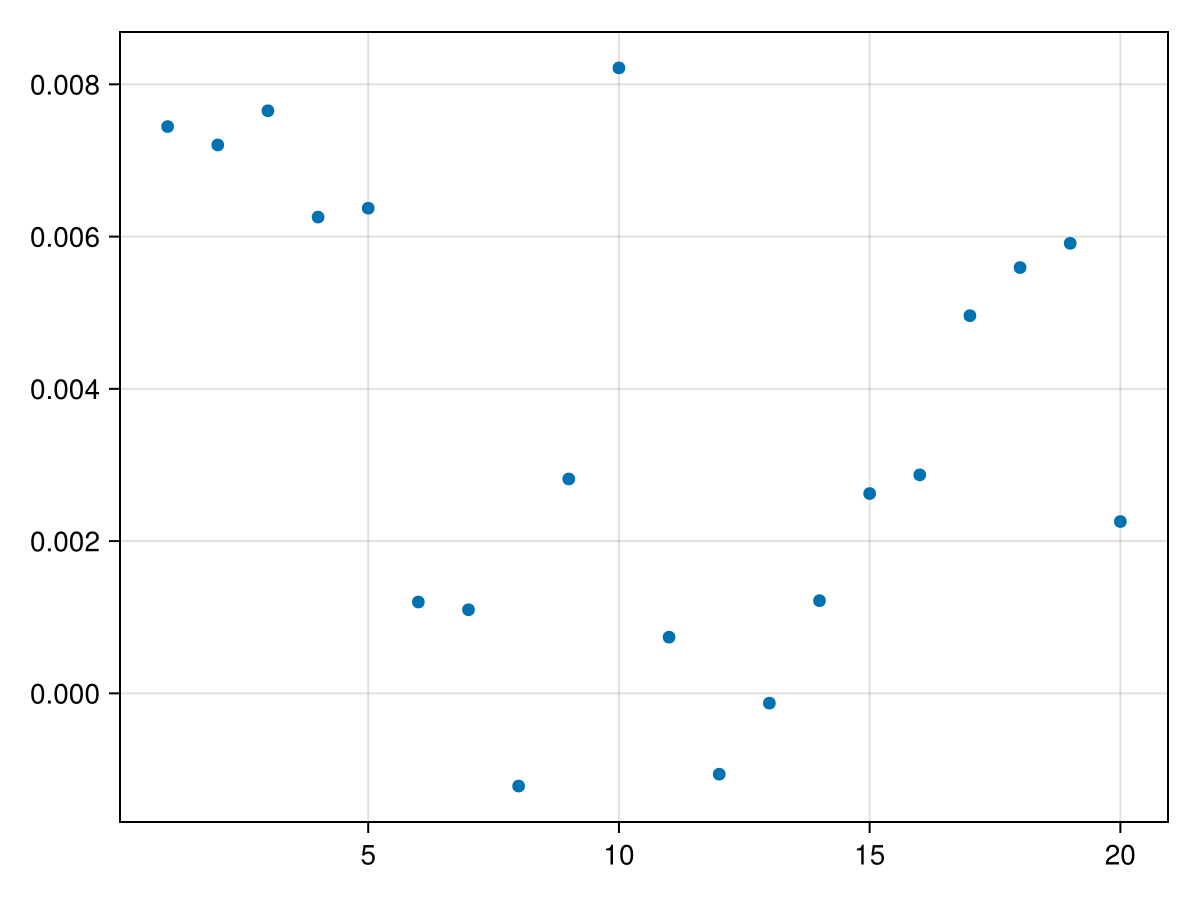

In [92]:
fig = Figure()
ax = Axis(fig[1,1])
scatter!(ax,  [m for m in mcqah])
fig

In [64]:
p = pimported
M, xmin, xmax = LMC.int_boundaries(p)
xbounds = [0, xmin[2]]
ybounds = [xmax[1]/2, xmax[2]]

2-element Vector{Float64}:
 0.027023694543358623
 0.046806411957319716

2-element Vector{Float64}:
  0.0
 -0.046806411957319716

### Test FS

In [86]:
# Define number of grid points
T = 5 * 1e3
νval = 2.5
it = argmin(abs.(s.ns .- νval))
n = 5
p = pimported
svp = simportedvp
sqah = simportedqah

pxxxvp = xxx_lmc_presets(ParamsHF(p, μ = svp.mus[it]), diagm(svp.ofmats[it]), T = T, fermi_surface = true) 
integrandvp(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxvp, q) 

pxxxqah = xxx_lmc_presets(ParamsHF(p, μ = sqah.mus[it]), diagm(sqah.ofmats[it]), T = T, fermi_surface = true) 
integrandqah(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxqah, q) 


M, xmin, xmax = LMC.int_boundaries(p)
# a = [0, xmin[2]];
# b = [xmax[1]/2, xmax[2]];
a = [-xmax[1], xmin[2]];
b = [xmax[1], xmax[2]];

# Generate grid points
x = range(a[1], b[1], length=n)
y = range(a[2], b[2], length=n)

# Evaluate f on the grid
Zvp = [integrandvp([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering
Zqah = [integrandqah([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering

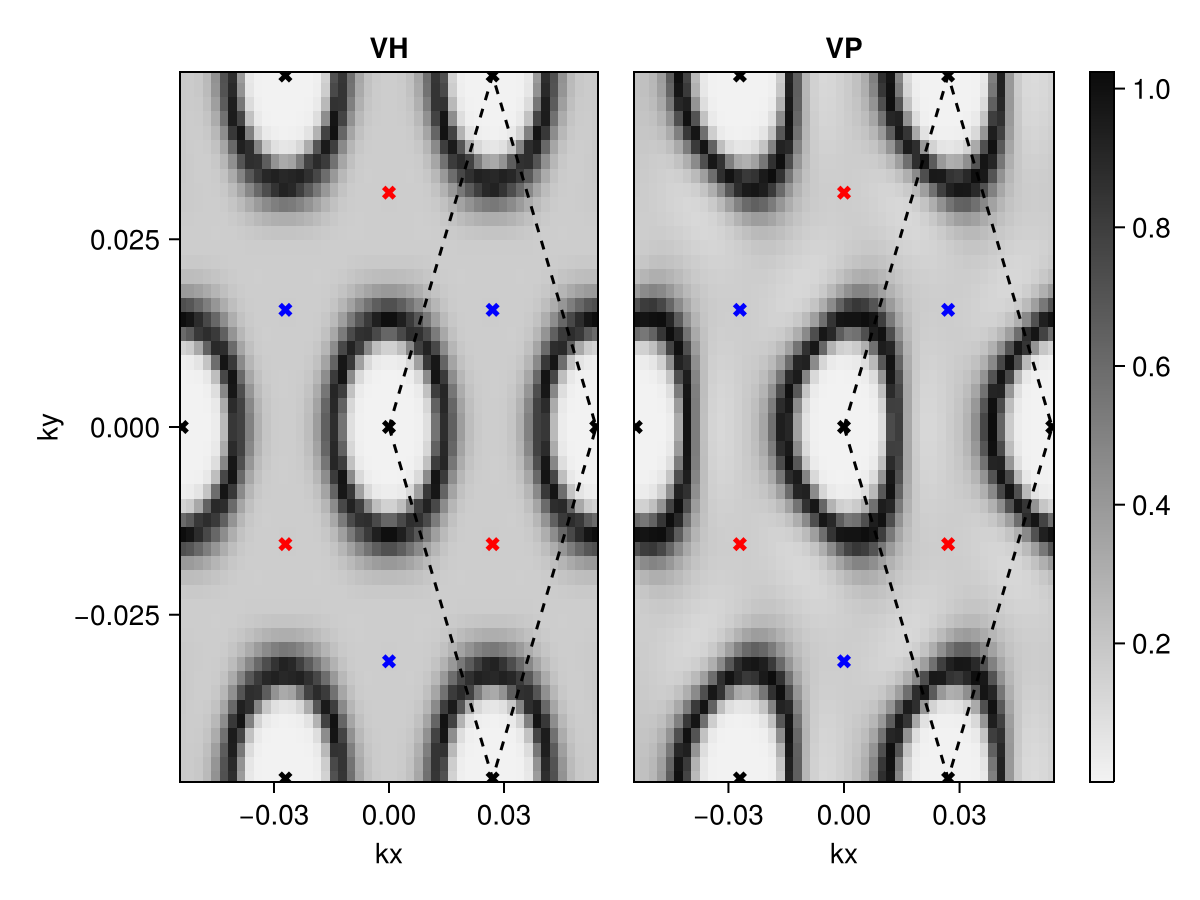

In [130]:

# Create the density plot
using CairoMakie
# Define number of grid points
T = 5 * 1e3
νval = 2.5
it = argmin(abs.(s.ns .- νval))
n = 5
p = pimported
svp = simportedvp
sqah = simportedqah

pxxxvp = xxx_lmc_presets(ParamsHF(p, μ = svp.mus[it]), diagm(svp.ofmats[it]), T = T, fermi_surface = true) 
integrandvp(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxvp, q) 

pxxxqah = xxx_lmc_presets(ParamsHF(p, μ = sqah.mus[it]), diagm(sqah.ofmats[it]), T = T, fermi_surface = true) 
integrandqah(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxqah, q) 


M, xmin, xmax = LMC.int_boundaries(p)
# a = [0, xmin[2]];
# b = [xmax[1]/2, xmax[2]];
a = [-xmax[1], xmin[2]];
b = [xmax[1], xmax[2]];

# Generate grid points
x = range(a[1], b[1], length=n)
y = range(a[2], b[2], length=n)

# Evaluate f on the grid
Zvp = [integrandvp([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering
Zqah = [integrandqah([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering


fig = Figure()
vis = 1e21
ϵ = abs(xmin[2])/100
ax1 = Axis(fig[1, 1], xlabel="kx", ylabel="ky", title="VH")
ax2 = Axis(fig[1, 2], xlabel="kx", ylabel="ky", title="VP")
val = maximum(abs.(Zqah))
# heatmap!(ax, x, y, Z, colormap=:redsblues)#, colorrange=(-1, 1.0).*vis)
hm = heatmap!(ax1, x, y, -Zqah ./val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
BZdecorations!(p, ax1)

hm = heatmap!(ax2, x, y, -Zvp ./ val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
BZdecorations!(p, ax2)
xlims!(ax1, a[1]-ϵ, b[1]+ϵ)
ylims!(ax1, a[2]-ϵ, b[2]+ϵ)

xlims!(ax2, a[1]-ϵ, b[1]+ϵ)
ylims!(ax2, a[2]-ϵ, b[2]+ϵ)
cb = Colorbar(fig[1, 3], hm)
hideydecorations!(ax2)

# Colorbar(fig[1,2], ax)  # Add a colorbar
fig

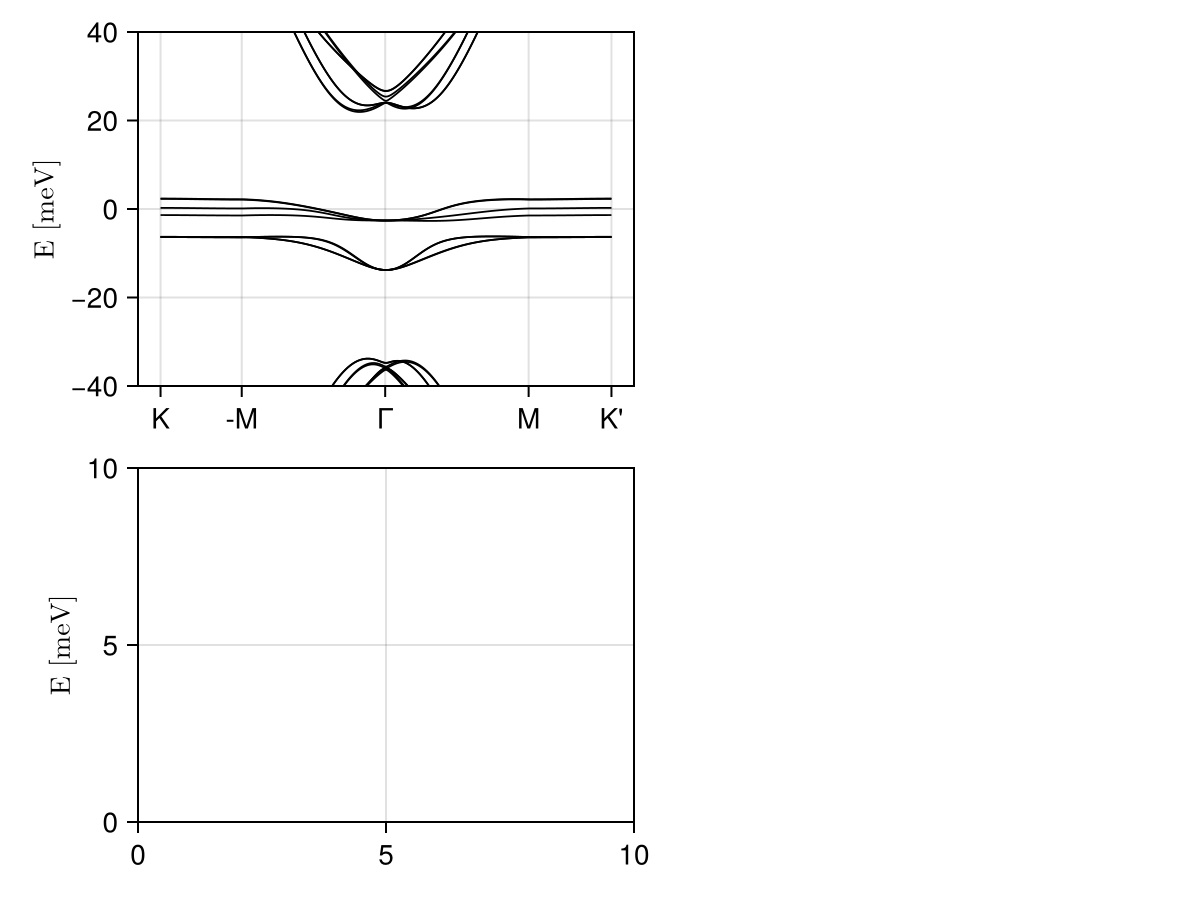

In [82]:

it = 100

fig = Figure()
ax1 = Axis(fig[1,1], ylabel = L"$\text{E [meV]}$")
ax2 = Axis(fig[2,1], ylabel = L"$\text{E [meV]}$")
ga = fig[1:2,2] = GridLayout()

LMC.plotmybands!(ax1, real.(LMC.bands(ParamsHF(p, μ = s.mus[it]), diagm(s.ofmats[it]), 101)),
      ylimits = [-40,40], color = :black)
# LMC.plotmybands!(ax2, real.(LMC.bands(ParamsHF(p, μ = 0, sigmaz = 5), ones(8),  101)), 
#       ylimits = ylims, xlimits = xlimits, color = :black, linewidth = linewidth)
    
    
fig
